# Preparing Data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from scipy.stats import norm, probplot
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df_by_movie = pd.read_csv("../../Data/3. AnalysisData/df_by_movie_v5.csv")

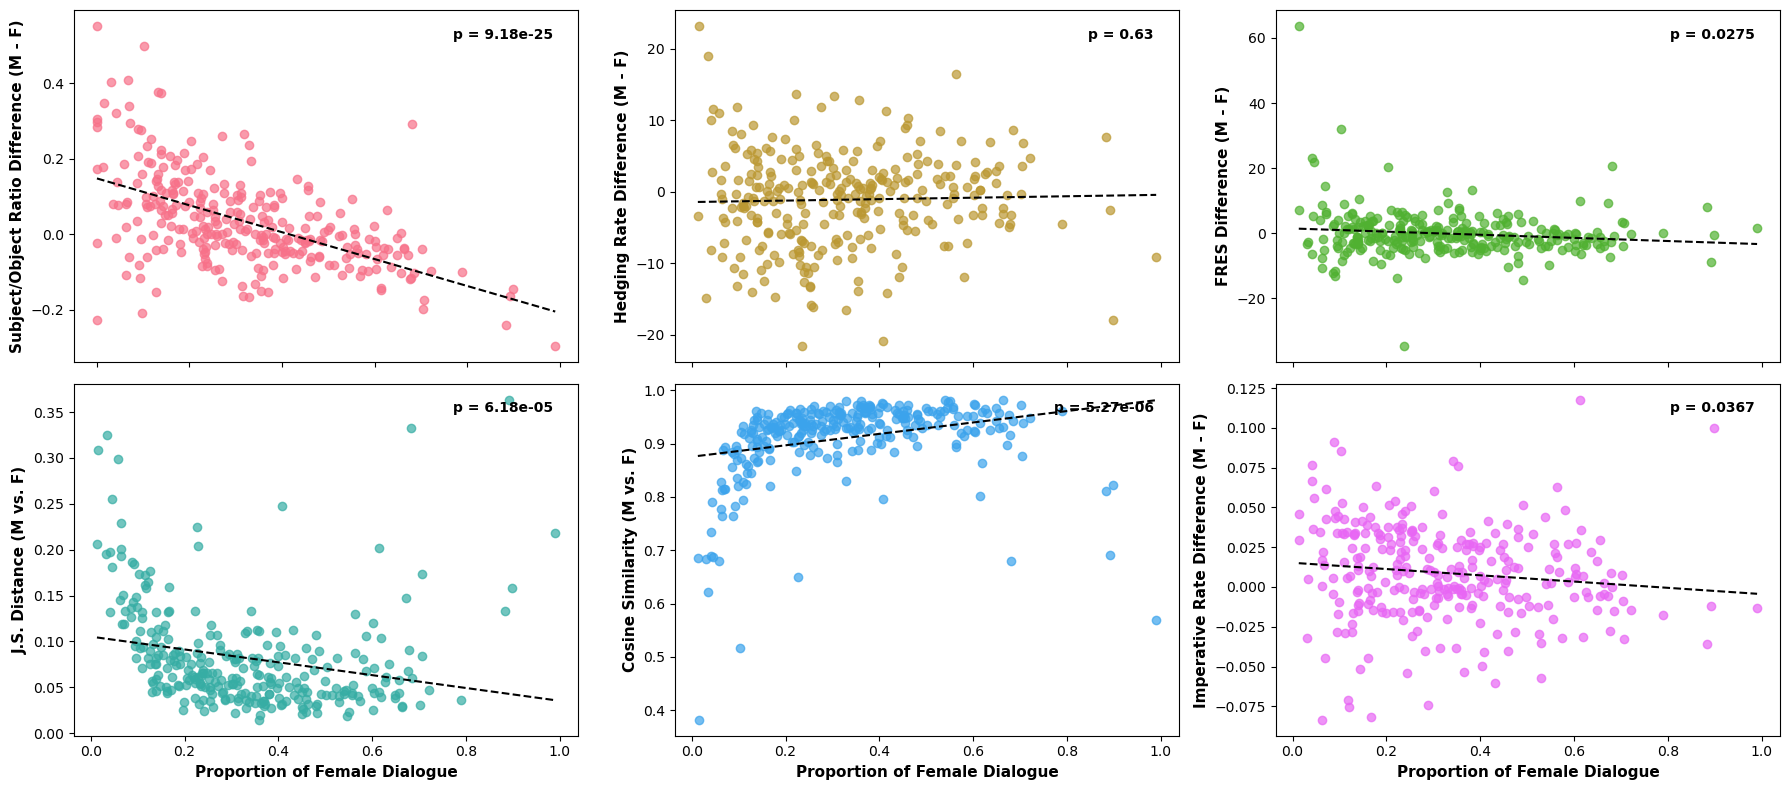

In [10]:
# Define metrics and their labels
metrics = [
    'ratio_diff',
    'hedge_diff',
    'flesch_diff_m_f',
    'jsd_m_f',
    'cossim',
    'diff_imperatives_normed'
]

labels = {
    'ratio_diff': 'Subject/Object Ratio Difference (M - F)',
    'hedge_diff': 'Hedging Rate Difference (M - F)',
    'flesch_diff_m_f': 'FRES Difference (M - F)',
    'jsd_m_f': 'J.S. Distance (M vs. F)',
    'cossim': 'Cosine Similarity (M vs. F)',
    'diff_imperatives_normed': 'Imperative Rate Difference (M - F)'
}

colors = sns.color_palette("husl", len(metrics))

# Create subplot grid
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    ax = axs[i]
    df_subset = df_by_movie[['prop_fem', metric]].dropna()
    
    x = df_subset['prop_fem']
    y = df_subset[metric]
    
    # Scatter plot
    ax.scatter(x, y, color=colors[i], alpha=0.7)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=1.5)

    ax.text(
    0.95, 0.95,
    f'p = {p_value:.3g}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    fontweight='bold'
)

    
    # Y label
    ax.set_ylabel(labels[metric], fontsize=11, fontweight='bold')

    # X label only for bottom row
    if i >= 3:
        ax.set_xlabel("Proportion of Female Dialogue", fontsize=11, fontweight='bold')
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])



# Final layout
plt.tight_layout()
plt.show()

# Fit OLS to each


--- Subject/Object Ratio Difference (M - F) ---
Slope: -0.3565
95% CI for slope: [-0.4187, -0.2944]
                            OLS Regression Results                            
Dep. Variable:             ratio_diff   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     127.5
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           9.18e-25
Time:                        13:50:08   Log-Likelihood:                 246.17
No. Observations:                 293   AIC:                            -488.3
Df Residuals:                     291   BIC:                            -481.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

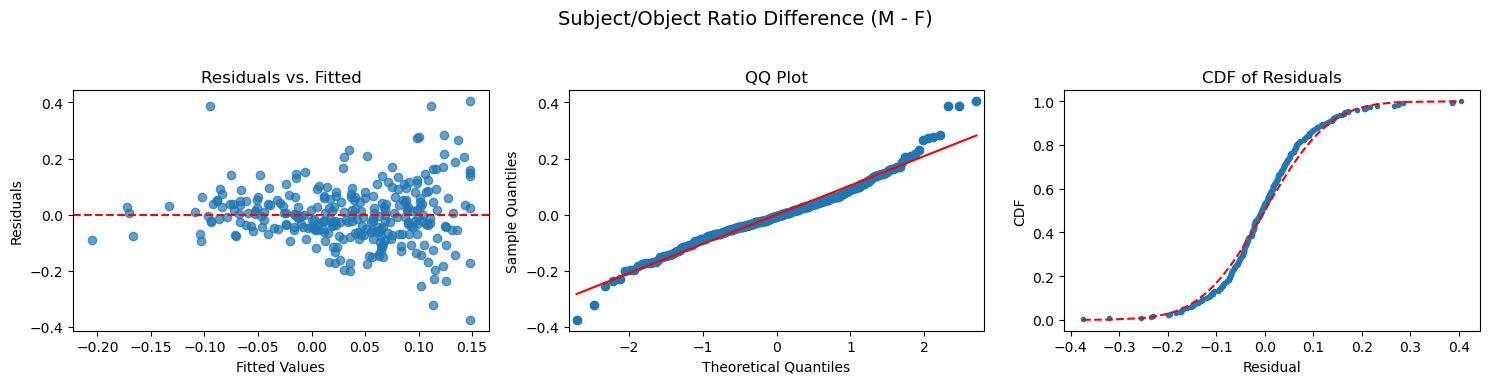


--- Hedging Rate Difference (M - F) ---
Slope: 1.0114
95% CI for slope: [-3.1111, 5.1340]
                            OLS Regression Results                            
Dep. Variable:             hedge_diff   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2332
Date:                Wed, 06 Aug 2025   Prob (F-statistic):              0.630
Time:                        13:50:08   Log-Likelihood:                -949.57
No. Observations:                 286   AIC:                             1903.
Df Residuals:                     284   BIC:                             1910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

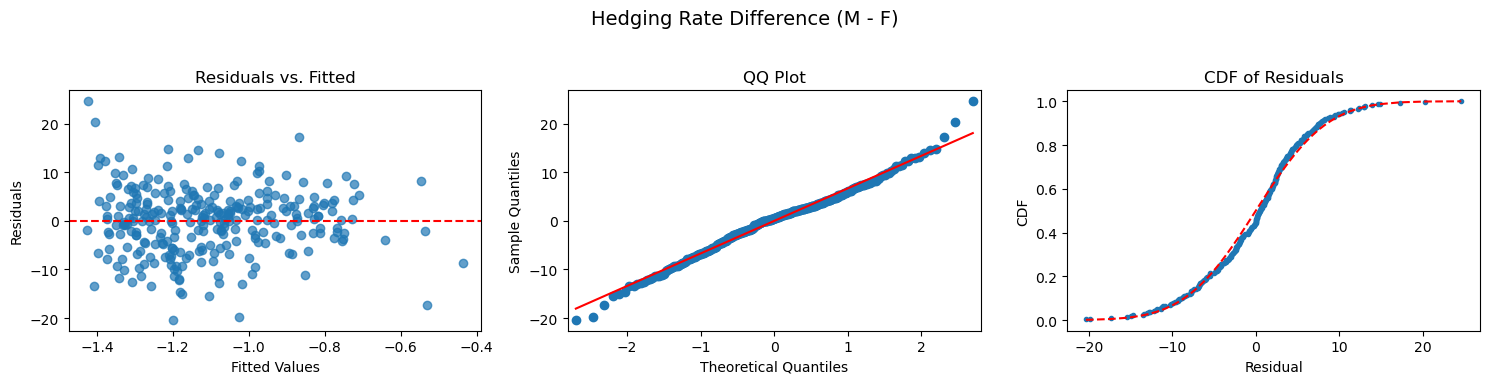


--- FRES Difference (M - F) ---
Slope: -4.8170
95% CI for slope: [-9.0974, -0.5366]
                            OLS Regression Results                            
Dep. Variable:        flesch_diff_m_f   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     4.907
Date:                Wed, 06 Aug 2025   Prob (F-statistic):             0.0275
Time:                        13:50:09   Log-Likelihood:                -960.32
No. Observations:                 286   AIC:                             1925.
Df Residuals:                     284   BIC:                             1932.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

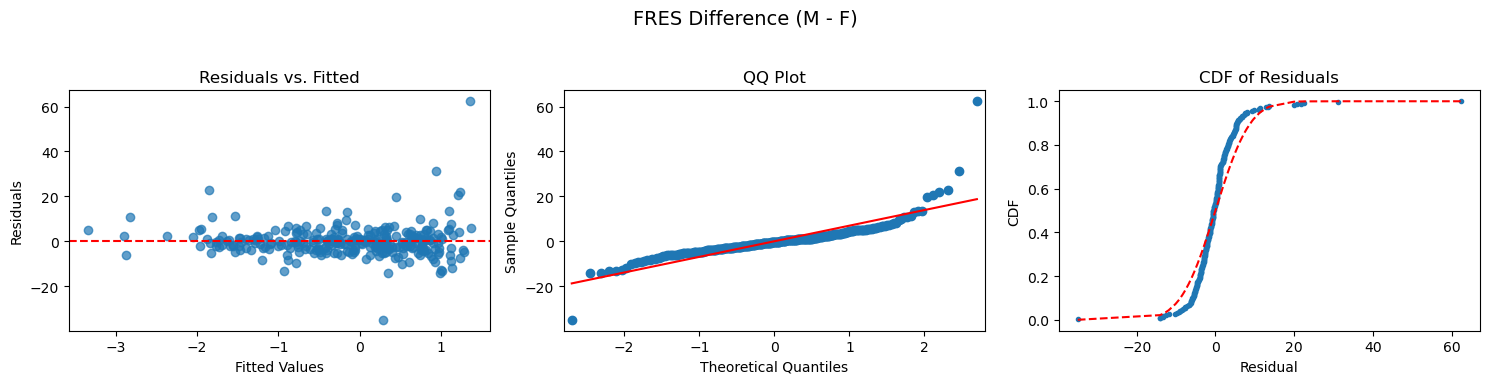


--- J.S. Distance (M vs. F) ---
Slope: -0.0700
95% CI for slope: [-0.1039, -0.0361]
                            OLS Regression Results                            
Dep. Variable:                jsd_m_f   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     16.54
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           6.18e-05
Time:                        13:50:09   Log-Likelihood:                 423.55
No. Observations:                 286   AIC:                            -843.1
Df Residuals:                     284   BIC:                            -835.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

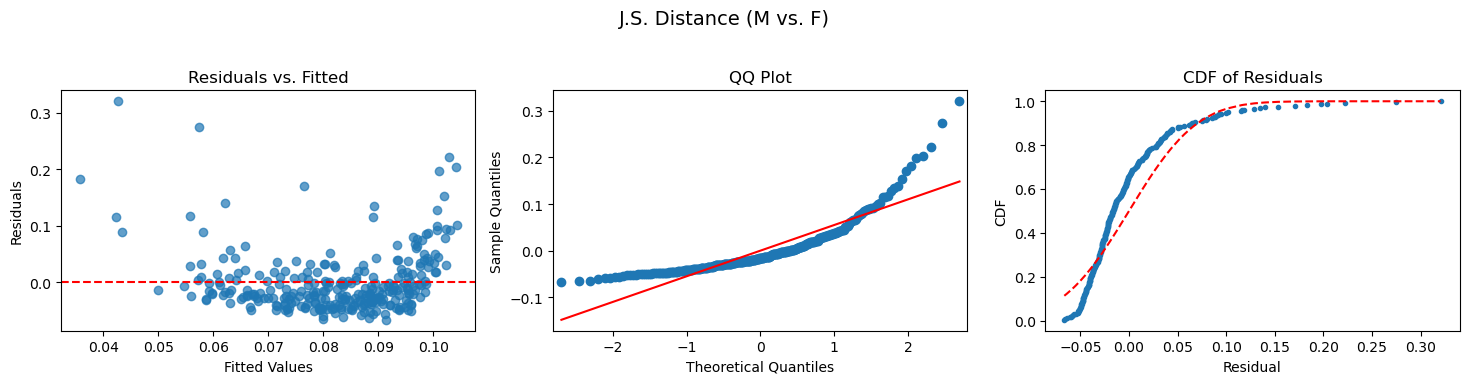


--- Cosine Similarity (M vs. F) ---
Slope: 0.1070
95% CI for slope: [0.0617, 0.1524]
                            OLS Regression Results                            
Dep. Variable:                 cossim   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     21.55
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           5.27e-06
Time:                        13:50:09   Log-Likelihood:                 339.99
No. Observations:                 286   AIC:                            -676.0
Df Residuals:                     284   BIC:                            -668.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

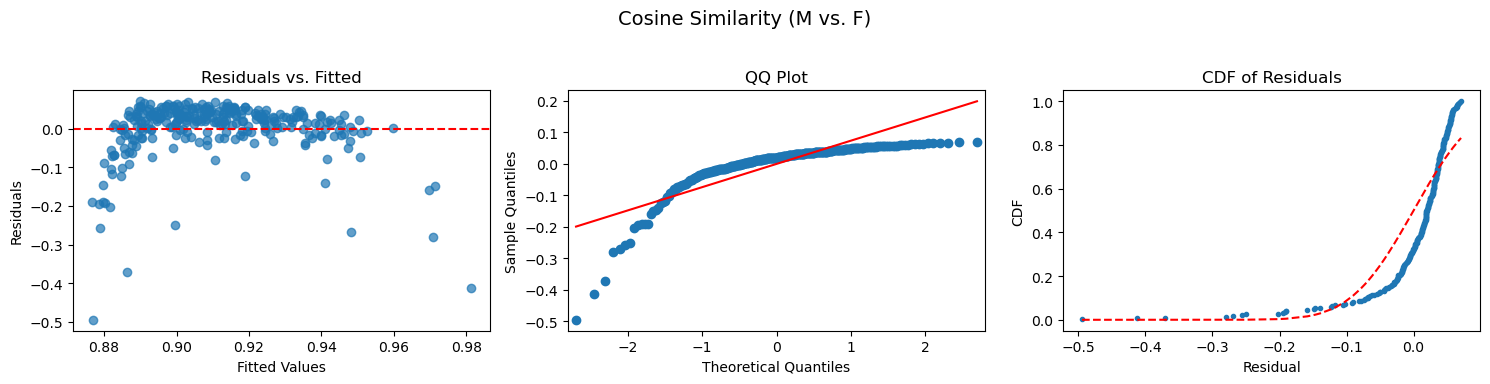


--- Imperative Rate Difference (M - F) ---
Slope: -0.0197
95% CI for slope: [-0.0381, -0.0012]
                               OLS Regression Results                              
Dep. Variable:     diff_imperatives_normed   R-squared:                       0.015
Model:                                 OLS   Adj. R-squared:                  0.012
Method:                      Least Squares   F-statistic:                     4.404
Date:                     Wed, 06 Aug 2025   Prob (F-statistic):             0.0367
Time:                             13:50:09   Log-Likelihood:                 597.37
No. Observations:                      286   AIC:                            -1191.
Df Residuals:                          284   BIC:                            -1183.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.0

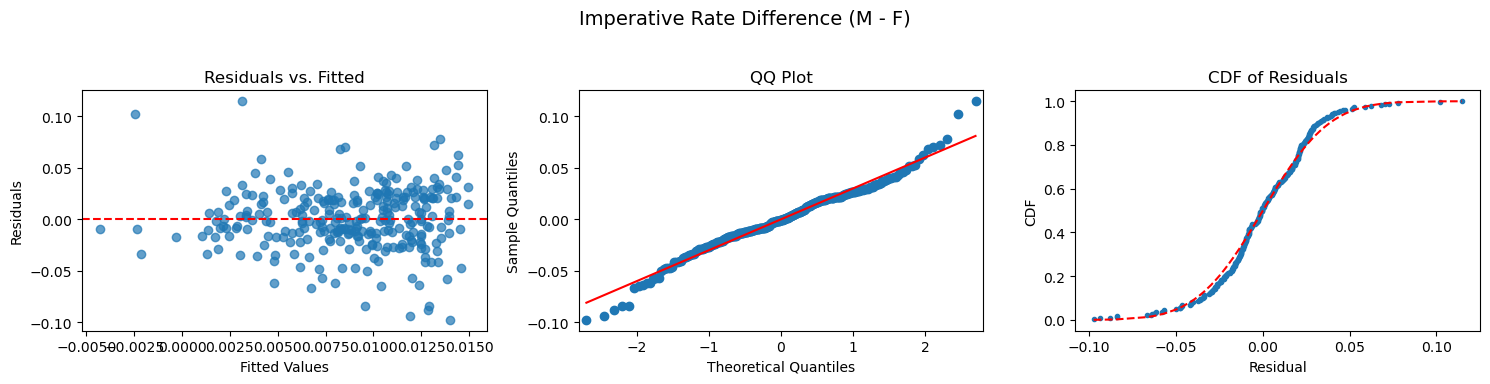

In [11]:
for i, metric in enumerate(metrics):
    df_subset = df_by_movie[['prop_fem', metric]].dropna()
    x = df_subset['prop_fem']
    y = df_subset[metric]

    # Add constant for OLS intercept
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    fitted_vals = model.fittedvalues
    residuals = model.resid
    slope = model.params['prop_fem']
    conf_int = model.conf_int().loc['prop_fem']

    print(f"\n--- {labels[metric]} ---")
    print(f"Slope: {slope:.4f}")
    print(f"95% CI for slope: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")
    print(model.summary())

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Residuals vs. Fitted
    axs[0].scatter(fitted_vals, residuals, alpha=0.7)
    axs[0].axhline(0, color='red', linestyle='--')
    axs[0].set_title('Residuals vs. Fitted')
    axs[0].set_xlabel('Fitted Values')
    axs[0].set_ylabel('Residuals')
    
    # 2. QQ Plot
    sm.qqplot(residuals, line='s', ax=axs[1])
    axs[1].set_title('QQ Plot')
    
    # 3. CDF Plot of Residuals
    sorted_resid = np.sort(residuals)
    cdf = np.arange(1, len(sorted_resid)+1) / len(sorted_resid)
    axs[2].plot(sorted_resid, cdf, marker='.', linestyle='none')
    axs[2].plot(sorted_resid, norm.cdf(sorted_resid, loc=np.mean(residuals), scale=np.std(residuals)), 'r--')
    axs[2].set_title('CDF of Residuals')
    axs[2].set_xlabel('Residual')
    axs[2].set_ylabel('CDF')
    
    plt.suptitle(labels[metric], fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Conclusion
### Subject/object
- negative relationship between subj obj and female dialogue
- 95% CI for Slope: [-0.4187, -0.2944]
- The true value of the slope is almost certainly negative (significant effect).
- R-squared: 0.305 (strong)
- p-value for slope: < 0.001: The relationship is highly statistically significant.
- The residuals are not perfectly normal

### Hedging
- Slope: 1.01
- 95% CI: [-3.11, 5.13] (includes zero)
- R²: 0.001 (0.1% of variance explained — almost none)
- p-value: 0.630 (not significant)

 ---> No relationship

### FRES (not perfect fit)
- slope = -4.8170
- 95% CI [-9.0974, -0.5366]
- R^2 0.014 (small effect)

### JS Distance (doesn't fit OLS)
- Slope: -0.07
- 95% CI: [-0.104, -0.036] (does not include zero)
- R²: 0.055 (small effect)
- p-value: <0.001 (statistically significant)

### Cosine Similarity (doesn't fit OLS)
- Slope: 0.107
- 95% CI: [0.062, 0.152] (does not include zero)
- R²: 0.071 (7.1% of variance explained — small but meaningful)
- p-value: <0.001 (statistically significant)
statistically significant positive relationship

### Imperative Rate
- Slope: -0.0197
- 95% CI for slope: [-0.0381, -0.0012]
- small but statistically significant negative relationship
- effect is very small (R-squared = 0.015)
- residuals may not be perfectly normal

# Fit distribution


=== FRES ===


/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:6918: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)
/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


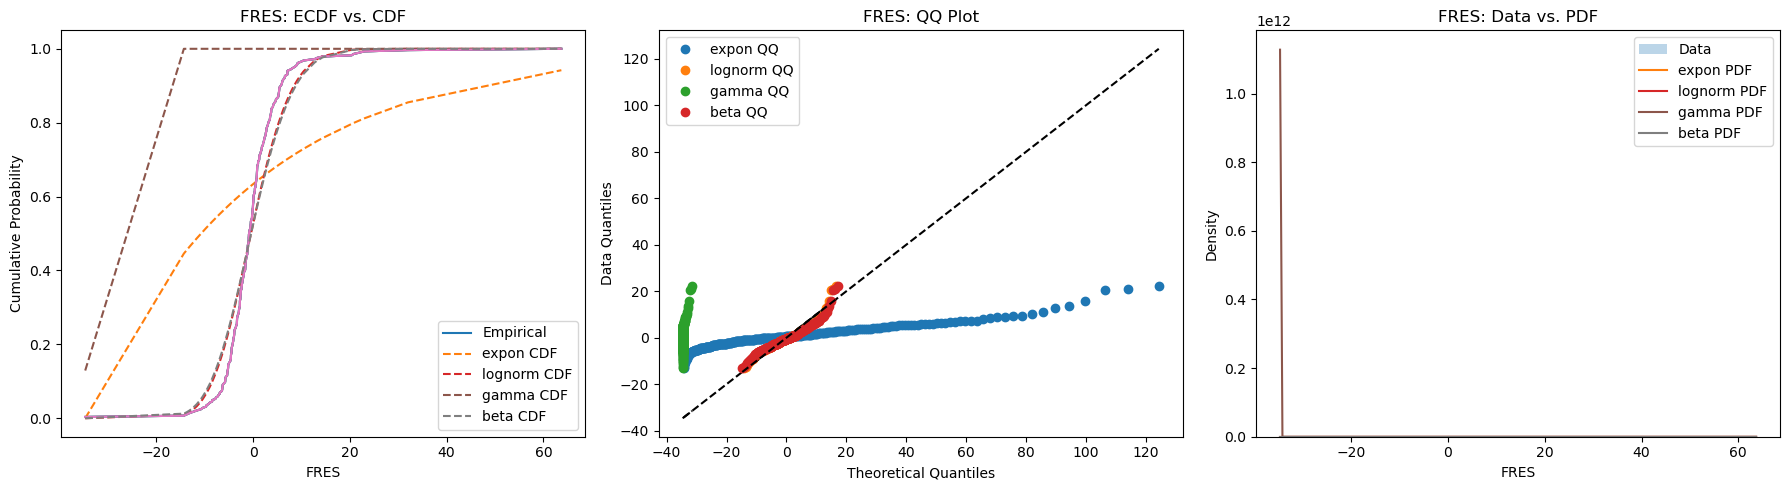

                                                                                params         logL  k          AIC    AIC_diff
lognorm                   (0.08851170859591355, -74.65307083794912, 74.20648806961388)  -944.134571  3  1894.269141    0.000000
   beta (61.964392485617736, 18741190.3435252, -54.03403630498228, 16304458.527197547)  -948.001355  4  1904.002709    9.733568
  expon                                        (-34.67687423498613, 34.52910712654373) -1298.955559  2  2601.911118  707.641976
  gamma                 (0.062040635987951856, -34.67687423498614, 2.5603864959945364) -5572.555882  3 11151.111764 9256.842622

=== JSD ===


/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


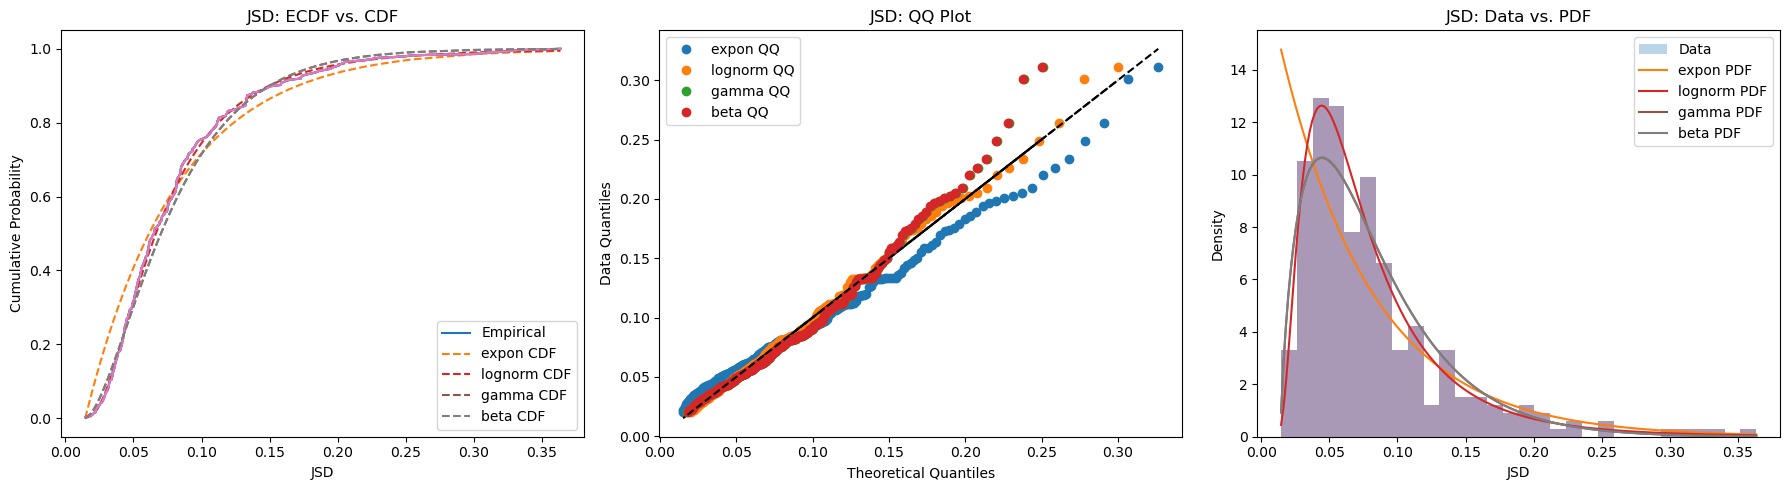

                                                                                  params       logL  k          AIC  AIC_diff
lognorm                 (0.6951415287559831, 0.008602682452376668, 0.057831738686814335) 513.346784  3 -1020.693567  0.000000
  gamma                 (1.8066105450443977, 0.013974568994212712, 0.037795626012012196) 506.779258  3 -1007.558516 13.135052
   beta (1.8144365496333377, 66707914890.35466, 0.01396319358670144, 2507730647.1922703) 506.777584  4 -1005.555167 15.138400
  expon                                         (0.0145317596929142, 0.0677229804901041) 484.006297  2  -964.012595 56.680973

=== COSINE ===


/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/brookeye/.local/share/mamba/envs/new_bechdel_env/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


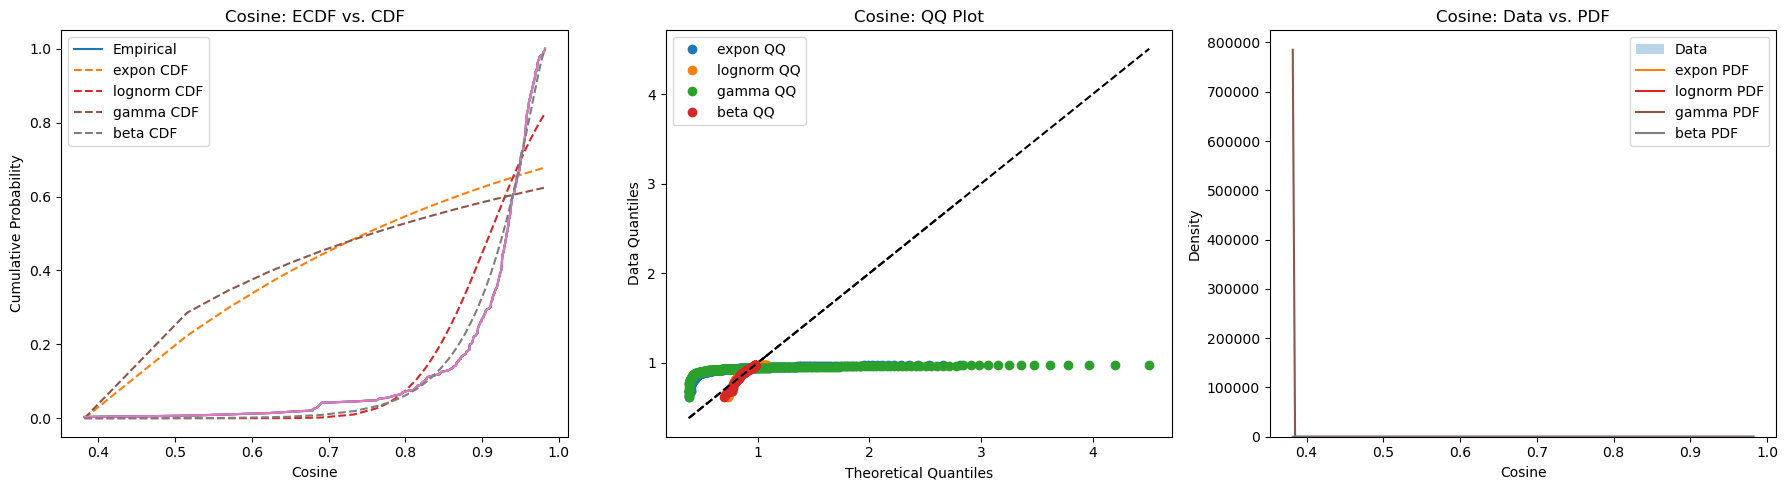

                                                                               params        logL  k         AIC    AIC_diff
   beta (107822746.42815086, 1.34317823418076, -5775157.361419957, 5775158.343675848)  473.601661  4 -939.203321    0.000000
lognorm                (2.333001747828336e-06, -32767.61792916058, 32768.52820976903)  329.527042  3 -653.054084  286.149237
  expon                                      (0.3820708394050598, 0.5282098582157722) -103.457178  2  210.914356 1150.117677
  gamma                  (0.6184045251371844, 0.3820708394050597, 1.1274046280122638) -176.772224  3  359.544447 1298.747768


In [20]:
metrics = {
    "FRES": df_by_movie['flesch_diff_m_f'],  # Flesch Reading Ease Score
    "JSD": df_by_movie['jsd_m_f'],  # Jensen-Shannon Distance
    "Cosine": df_by_movie['cossim'],  # Cosine Similarity
}

distributions = [
    ('expon', stats.expon), 
    ('lognorm', stats.lognorm), 
    ('gamma', stats.gamma),
    ('beta', stats.beta)
]

def ecdf(data):
    xs = np.sort(data)
    ys = np.arange(1, len(xs)+1) / len(xs)
    return xs, ys

for metric, data in metrics.items():
    data = data.dropna().values
    print(f"\n=== {metric.upper()} ===")
    results = []
    plt.figure(figsize=(18,5))
    
    # Fit distributions and gather stats
    for i, (name, dist) in enumerate(distributions):
        params = dist.fit(data)
        k = len(params)
        logL = np.sum(dist.logpdf(data, *params))
        AIC = 2*k - 2*logL
        results.append({
            "name": name,
            "params": params,
            "logL": logL,
            "k": k,
            "AIC": AIC,
        })
        
        # For ECDF vs Theoretical CDF
        xs, ys = ecdf(data)
        cdf_theory = dist.cdf(xs, *params)
        plt.subplot(1, 3, 1)
        plt.plot(xs, ys, label='Empirical' if i==0 else "")
        plt.plot(xs, cdf_theory, '--', label=f'{name} CDF')
        plt.title(f"{metric}: ECDF vs. CDF")
        plt.xlabel(metric)
        plt.ylabel("Cumulative Probability")
        plt.legend()
        
        # For QQ plot
        plt.subplot(1, 3, 2)
        qq_theory = dist.ppf(np.linspace(0.01, 0.99, len(data)), *params)
        qq_data = np.quantile(data, np.linspace(0.01, 0.99, len(data)))
        plt.plot(qq_theory, qq_data, 'o', label=f'{name} QQ')
        plt.plot(qq_theory, qq_theory, 'k--')
        plt.title(f"{metric}: QQ Plot")
        plt.xlabel('Theoretical Quantiles')
        plt.ylabel('Data Quantiles')
        plt.legend()
        
        # Histogram vs PDF
        plt.subplot(1, 3, 3)
        count, bins, _ = plt.hist(data, bins=30, density=True, alpha=0.3, label='Data' if i==0 else "")
        xfit = np.linspace(min(data), max(data), 200)
        plt.plot(xfit, dist.pdf(xfit, *params), label=f'{name} PDF')
        plt.title(f"{metric}: Data vs. PDF")
        plt.xlabel(metric)
        plt.ylabel("Density")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summarize results in DataFrame
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values("AIC").reset_index(drop=True)
    df_results["AIC_diff"] = df_results["AIC"] - df_results["AIC"].iloc[0]
    df_results = df_results.rename(columns={'name': '', 'params': 'params'})
    print(df_results[['', 'params', 'logL', 'k', 'AIC', 'AIC_diff']].to_string(index=False))

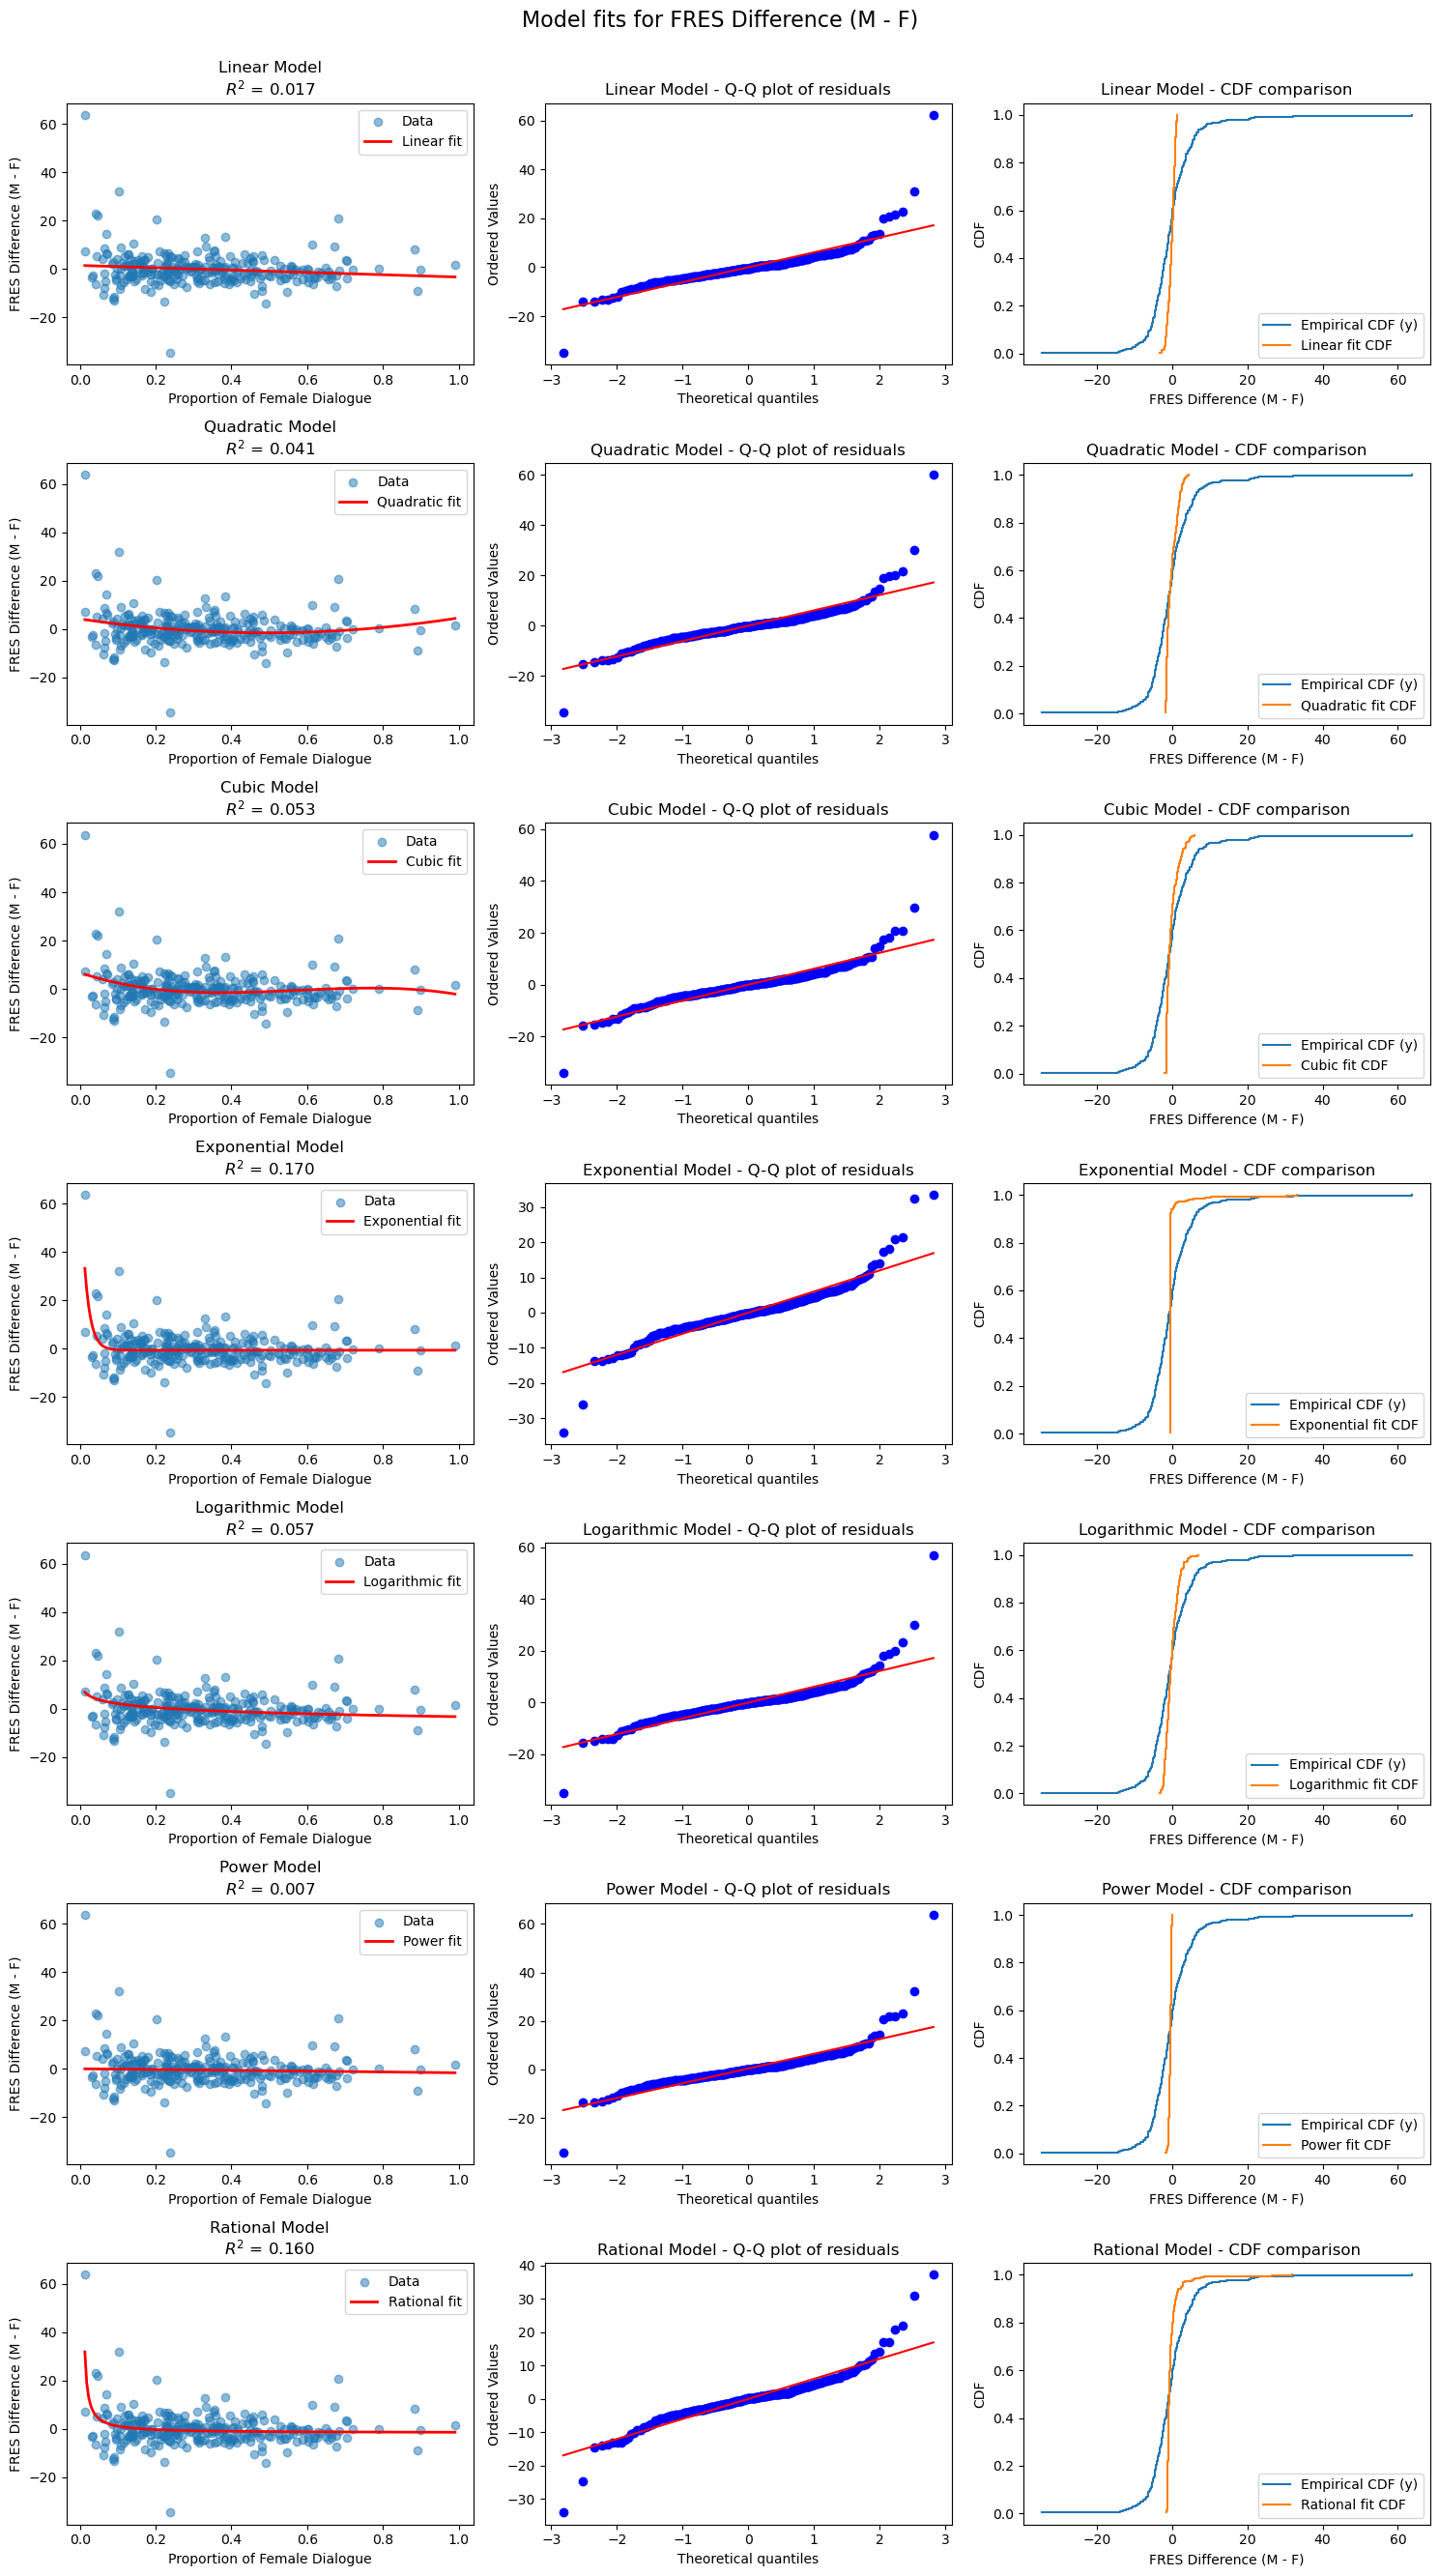

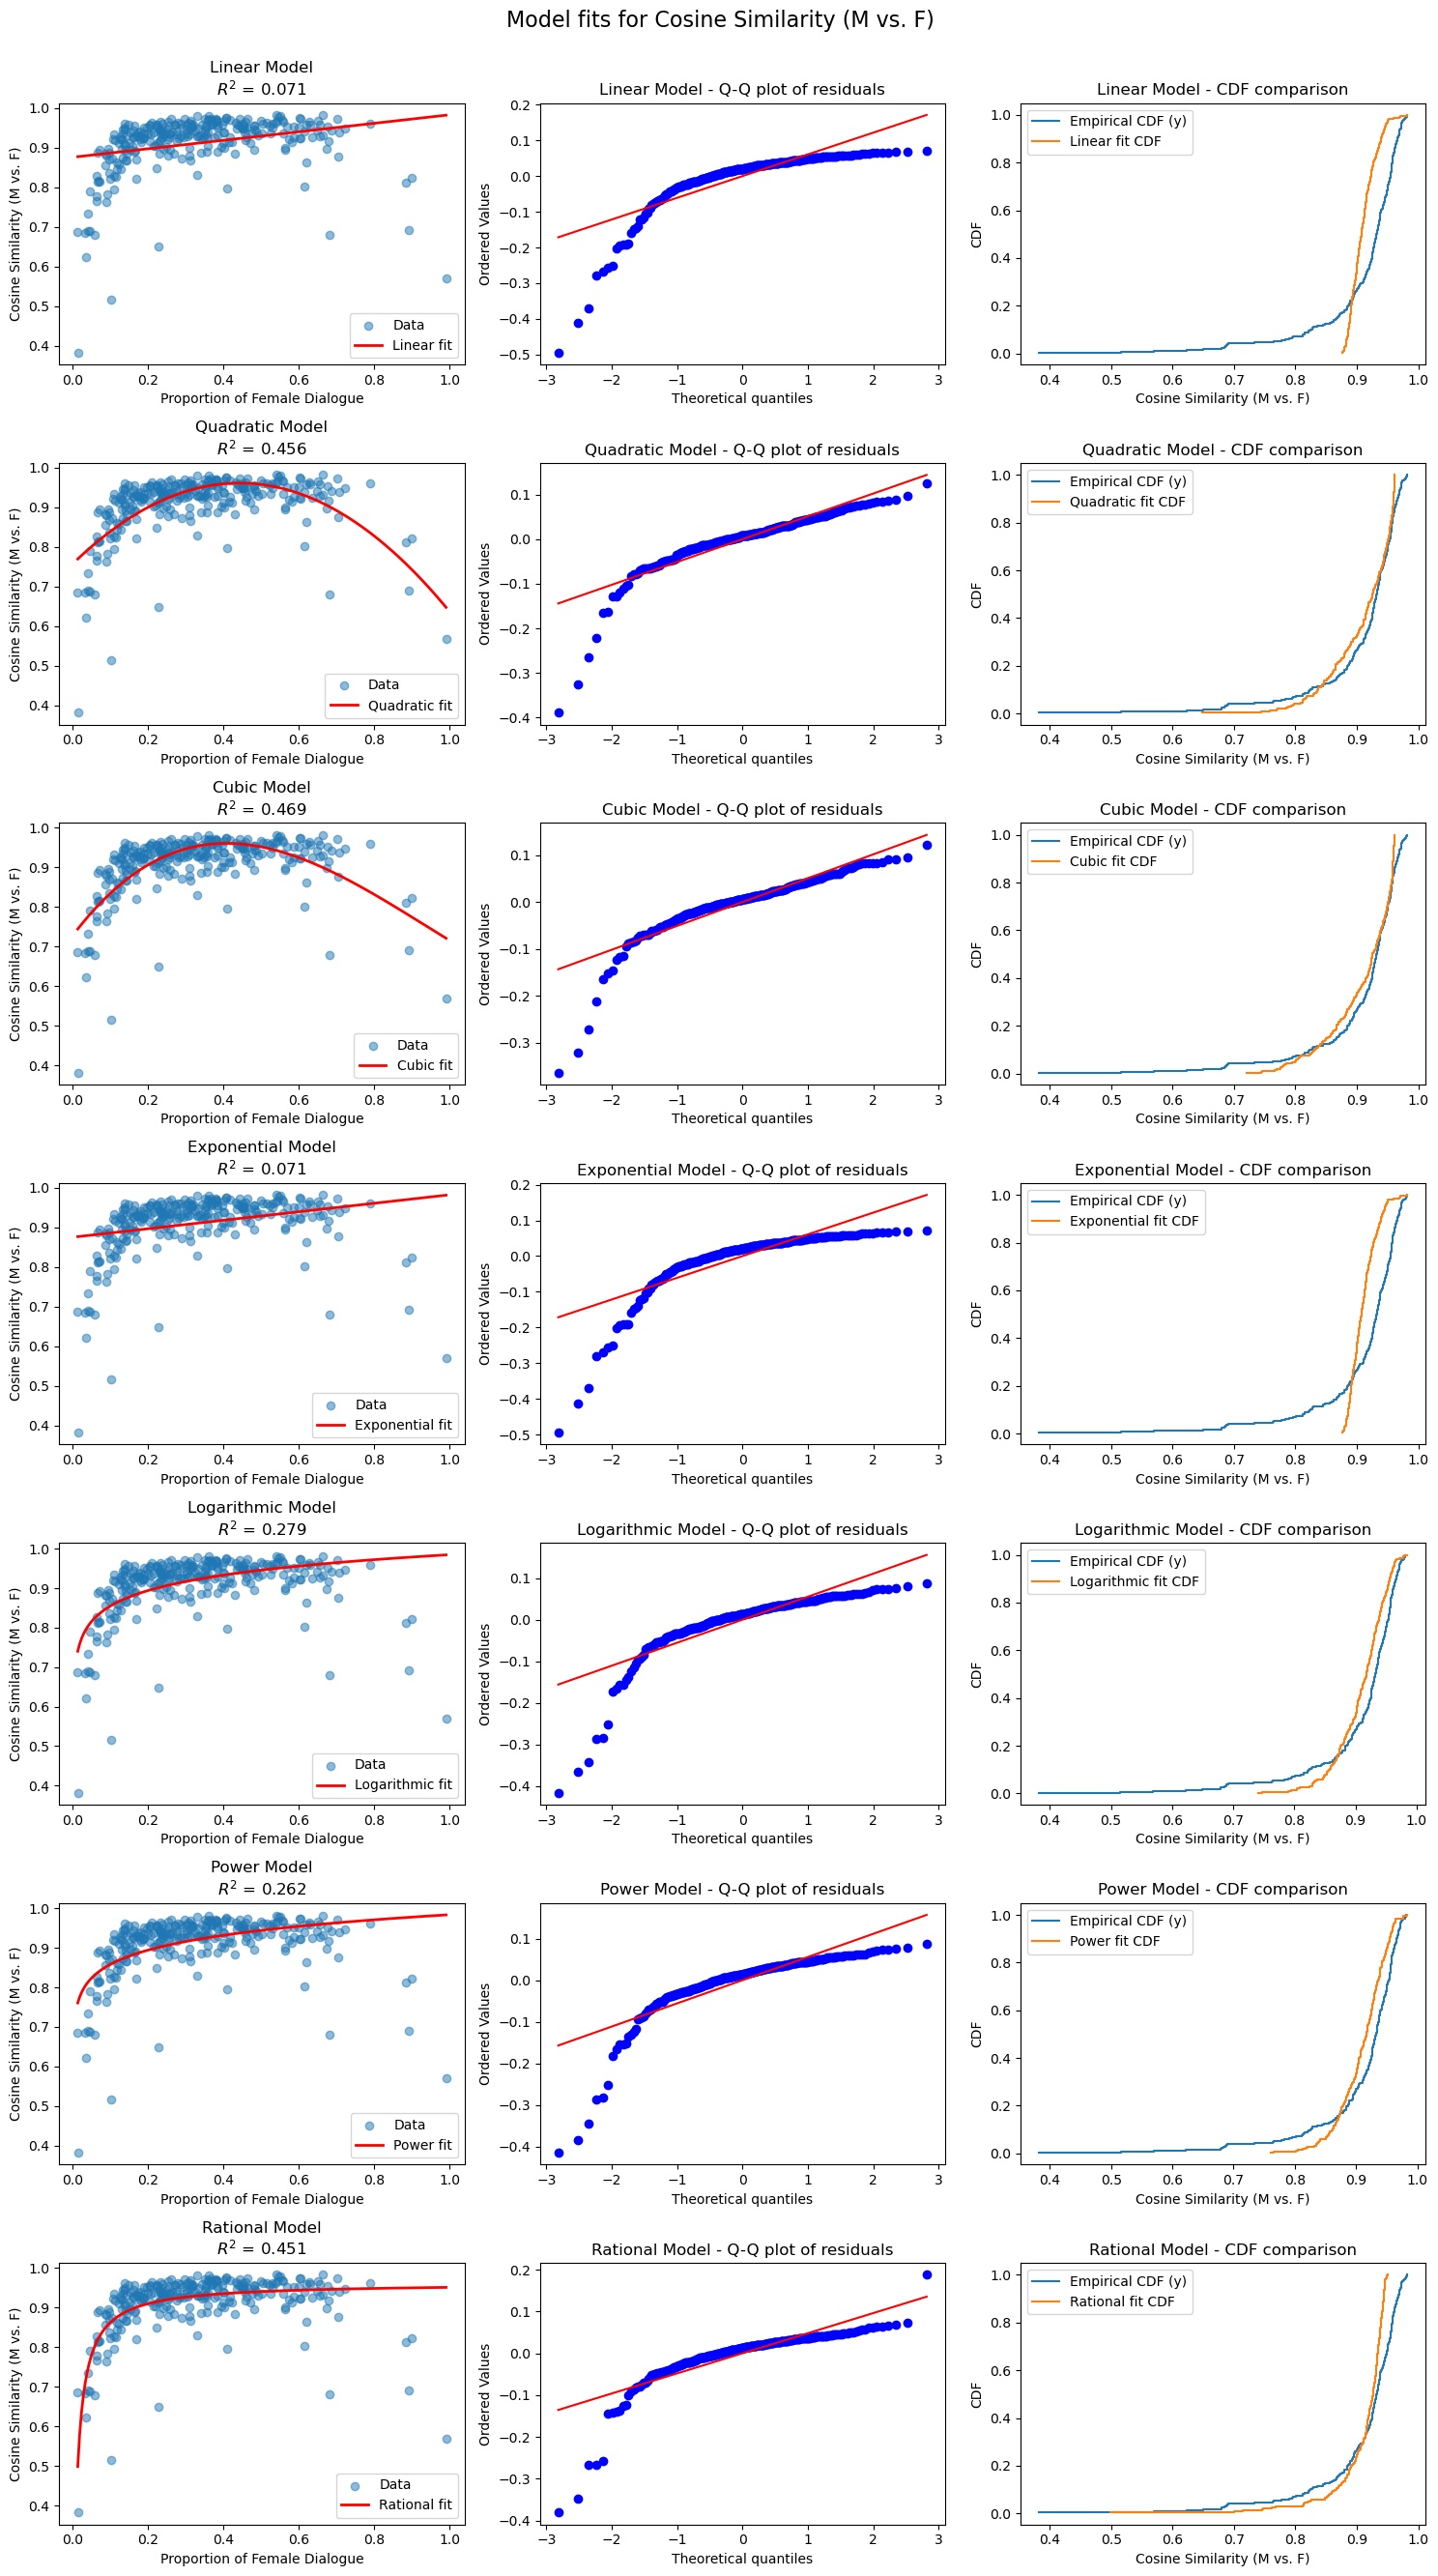

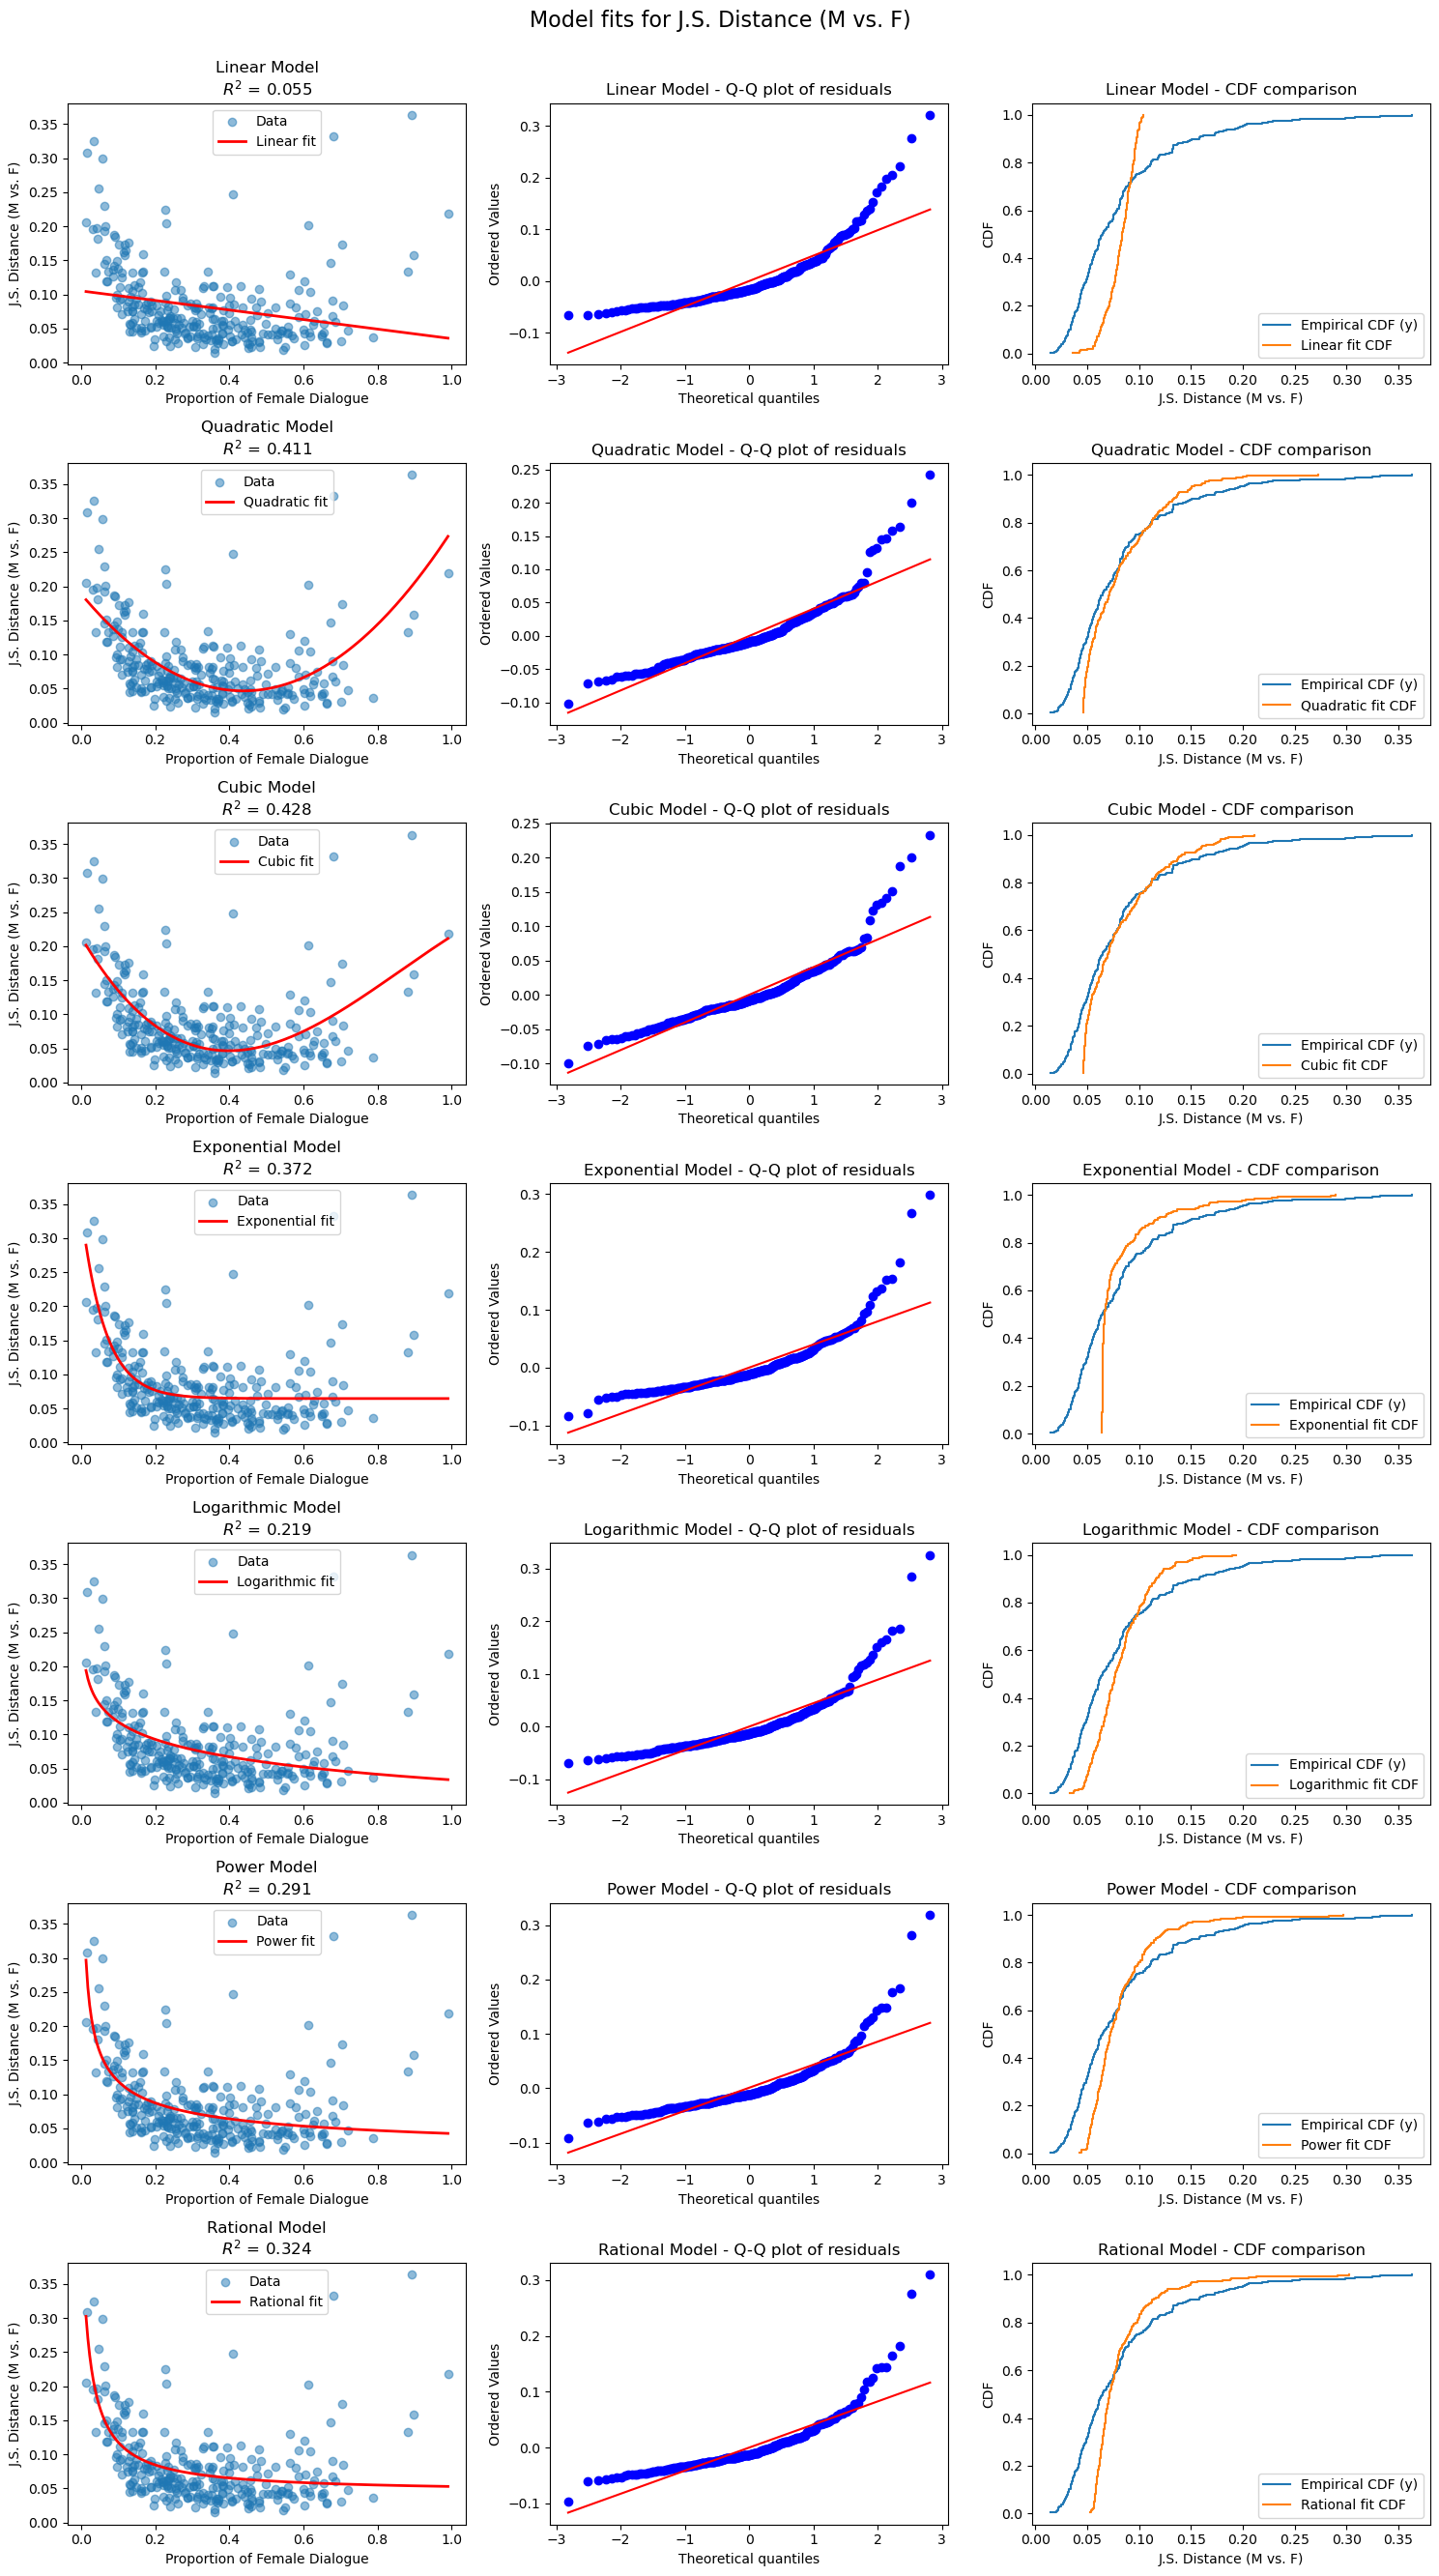

In [26]:
def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(-b * x) + c

def logarithmic(x, a, b):
    return a * np.log(x + 1e-8) + b

def powerlaw(x, a, b):
    return a * np.power(x + 1e-8, b)

def rational(x, a, b, c, d):
    return (a * x + b) / (c * x + d + 1e-8)

model_dict = {
    'Linear': linear,
    'Quadratic': quadratic,
    'Cubic': cubic,
    'Exponential': exponential,
    'Logarithmic': logarithmic,
    'Power': powerlaw,
    'Rational': rational
}

metrics = [
    "flesch_diff_m_f",
    "cossim",
    "jsd_m_f"
]

labels = {
    "flesch_diff_m_f": "FRES Difference (M - F)",
    "cossim": "Cosine Similarity (M vs. F)",
    "jsd_m_f": "J.S. Distance (M vs. F)"
}

for metric in metrics:
    df_subset = df_by_movie[["prop_fem", metric]].dropna()
    x = df_subset["prop_fem"].values
    y = df_subset[metric].values
    
    x_pred = np.linspace(np.min(x), np.max(x), 200)
    
    # Prepare subplots: rows = number of models, 3 columns (scatter+fit, QQ plot, CDF plot)
    n_models = len(model_dict)
    fig, axs = plt.subplots(n_models, 3, figsize=(15, 4 * n_models))
    fig.suptitle(f"Model fits for {labels[metric]}", fontsize=16, y=0.95)
    
    if n_models == 1:
        axs = np.array([axs])  # Ensure axs indexing works if only one model

    for row_i, (name, func) in enumerate(model_dict.items()):
        try:
            # Initial parameter guesses
            if func is exponential:
                p0 = (1, 1, 1)
            elif func is quadratic:
                p0 = (1, 1, 1)
            elif func is cubic:
                p0 = (1, 1, 1, 1)
            elif func is logarithmic:
                p0 = (1, 1)
            elif func is powerlaw:
                p0 = (1, 1)
            elif func is rational:
                p0 = (1, 1, 1, 1)
            else:
                p0 = (1, 1)

            popt, _ = curve_fit(func, x, y, p0=p0, maxfev=50000)
            
            y_fit = func(x, *popt)
            y_pred_fit = func(x_pred, *popt)
            r2 = r2_score(y, y_fit)
            
            residuals = y - y_fit
            sorted_res = np.sort(residuals)
            sorted_y_fit = np.sort(y_fit)
            
            # --- Plot 1: Scatter + Fitted Curve ---
            ax_scatter = axs[row_i, 0]
            ax_scatter.scatter(x, y, alpha=0.5, label='Data')
            ax_scatter.plot(x_pred, y_pred_fit, 'r-', lw=2, label=f"{name} fit")
            ax_scatter.set_xlabel("Proportion of Female Dialogue")
            ax_scatter.set_ylabel(labels[metric])
            ax_scatter.set_title(f"{name} Model\n$R^2$ = {r2:.3f}")
            ax_scatter.legend()

            # --- Plot 2: Q-Q Plot of Residuals ---
            ax_qq = axs[row_i, 1]
            stats.probplot(residuals, dist="norm", plot=ax_qq)
            ax_qq.set_title(f"{name} Model - Q-Q plot of residuals")

            # --- Plot 3: Empirical vs Model CDF of y ---
            ax_cdf = axs[row_i, 2]
            # Empirical CDF of observed y
            sorted_y = np.sort(y)
            ecdf = np.arange(1, len(sorted_y)+1) / len(sorted_y)
            ax_cdf.step(sorted_y, ecdf, label='Empirical CDF (y)', where='post')
            # CDF of predicted y (using fitted values at original x)
            sorted_y_fit = np.sort(y_fit)
            cdf_fit = np.arange(1, len(sorted_y_fit)+1) / len(sorted_y_fit)
            ax_cdf.step(sorted_y_fit, cdf_fit, label=f'{name} fit CDF', where='post')
            ax_cdf.set_xlabel(labels[metric])
            ax_cdf.set_ylabel("CDF")
            ax_cdf.legend()
            ax_cdf.set_title(f"{name} Model - CDF comparison")

        except Exception as e:
            # If fit fails, print and leave plots blank
            print(f"{name} model failed for {metric}: {e}")
            for j in range(3):
                axs[row_i, j].axis('off')
            continue

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import warnings

# Suppress runtime warnings for cleaner output
warnings.filterwarnings('ignore')

# Define the models (same as before)
def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(-b * x) + c

def logarithmic(x, a, b):
    return a * np.log(x + 1e-8) + b

def powerlaw(x, a, b):
    return a * np.power(x + 1e-8, b)

def rational(x, a, b, c, d):
    return (a * x + b) / (c * x + d + 1e-8)

model_dict = {
    'Linear': linear,
    'Quadratic': quadratic,
    'Cubic': cubic,
    'Exponential': exponential,
    'Logarithmic': logarithmic,
    'Power': powerlaw,
    'Rational': rational
}

metrics = ["flesch_diff_m_f", "cossim", "jsd_m_f"]
labels = {
    "flesch_diff_m_f": "FRES Difference (M - F)",
    "cossim": "Cosine Similarity (M vs. F)",
    "jsd_m_f": "J.S. Distance (M vs. F)"
}

# Initialize results storage
results = []

for metric in metrics:
    df_subset = df_by_movie[["prop_fem", metric]].dropna()
    x = df_subset["prop_fem"].values
    y = df_subset[metric].values
    
    for name, func in model_dict.items():
        try:
            # Initial parameter guesses
            if func is exponential:
                p0 = (1, 1, 1)
            elif func is quadratic:
                p0 = (1, 1, 1)
            elif func is cubic:
                p0 = (1, 1, 1, 1)
            elif func is logarithmic:
                p0 = (1, 1)
            elif func is powerlaw:
                p0 = (1, 1)
            elif func is rational:
                p0 = (1, 1, 1, 1)
            else:
                p0 = (1, 1)

            # Fit the model
            popt, pcov = curve_fit(func, x, y, p0=p0, maxfev=50000)
            
            # Calculate predictions and residuals
            y_fit = func(x, *popt)
            residuals = y - y_fit
            
            # Calculate goodness-of-fit metrics
            r2 = r2_score(y, y_fit)
            sse = np.sum(residuals**2)
            n = len(y)
            k = len(popt)
            
            # Calculate log-likelihood (assuming normal distribution of residuals)
            logL = -0.5 * n * (np.log(2 * np.pi) + np.log(sse/n) + 1)
            
            # Calculate AIC and BIC
            aic = 2 * k - 2 * logL
            bic = k * np.log(n) - 2 * logL
            
            # Calculate parameter confidence intervals
            perr = np.sqrt(np.diag(pcov))
            ci = 1.96 * perr  # 95% CI
            
            # Store results
            results.append({
                'Metric': metric,
                'Model': name,
                'Params': popt,
                'CI': ci,
                'logL': logL,
                'k': k,
                'AIC': aic,
                'BIC': bic,
                'R2': r2,
                'SSE': sse
            })
            
        except Exception as e:
            print(f"{name} model failed for {metric}: {e}")
            continue

# Create results dataframe
results_df = pd.DataFrame(results)

# Calculate AIC differences within each metric group
aic_diffs = []
for metric in metrics:
    metric_mask = results_df['Metric'] == metric
    min_aic = results_df.loc[metric_mask, 'AIC'].min()
    results_df.loc[metric_mask, 'AIC_diff'] = results_df.loc[metric_mask, 'AIC'] - min_aic

# Create a summary table
summary_table = results_df[['Metric', 'Model', 'k', 'logL', 'AIC', 'AIC_diff', 'R2']].copy()

# Function to format parameter equations with CIs
def format_equation(row):
    model_name = row['Model']
    params = row['Params']
    ci = row['CI']
    metric = row['Metric']
    
    if model_name == 'Linear':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * x + {params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Quadratic':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * x² + {params[1]:.3f}±{ci[1]:.3f} * x + "
              f"{params[2]:.3f}±{ci[2]:.3f}")
    elif model_name == 'Cubic':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * x³ + {params[1]:.3f}±{ci[1]:.3f} * x² + "
              f"{params[2]:.3f}±{ci[2]:.3f} * x + {params[3]:.3f}±{ci[3]:.3f}")
    elif model_name == 'Exponential':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * exp(-{params[1]:.3f}±{ci[1]:.3f} * x) + "
              f"{params[2]:.3f}±{ci[2]:.3f}")
    elif model_name == 'Logarithmic':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * log(x) + {params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Power':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * x^{params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Rational':
        eq = (f"({params[0]:.3f}±{ci[0]:.3f} * x + {params[1]:.3f}±{ci[1]:.3f}) / "
              f"({params[2]:.3f}±{ci[2]:.3f} * x + {params[3]:.3f}±{ci[3]:.3f})")
    
    return f"y = {eq}"

results_df['Equation'] = results_df.apply(format_equation, axis=1)

# Create best fit equations table
best_fits = results_df.loc[results_df.groupby('Metric')['AIC'].idxmin()][
    ['Metric', 'Model', 'Equation', 'AIC', 'AIC_diff', 'R2']
].copy()

# Display the results
print("\nSummary Table of All Models:")
display(summary_table.sort_values(['Metric', 'AIC']))

print("\nBest Fit Equations for Each Metric:")
display(best_fits)


Summary Table of All Models:


,Metric,Model,k,logL,AIC,AIC_diff,R2
9,cossim,Cubic,4,419.971316,-831.942632,0.000000,0.468722
8,cossim,Quadratic,3,416.466825,-826.933650,5.008982,0.455541
13,cossim,Rational,4,415.170717,-822.341435,9.601198,0.450584
11,cossim,Logarithmic,2,376.323904,-748.647808,83.294824,0.279092
12,cossim,Power,2,372.955915,-741.911829,90.030803,0.261911
7,cossim,Linear,2,339.986955,-675.973910,155.968722,0.070529
10,cossim,Exponential,3,339.985659,-673.971318,157.971314,0.070520
3,flesch_diff_m_f,Exponential,3,-936.157894,1878.315789,0.000000,0.169799
6,flesch_diff_m_f,Rational,4,-937.889946,1883.779893,5.464104,0.159683
4,flesch_diff_m_f,Logarithmic,2,-954.335535,1912.671071,34.355282,0.057266



Best Fit Equations for Each Metric:


,Metric,Model,Equation,AIC,AIC_diff,R2
9,cossim,Cubic,y = 0.699±0.518 * x³ + -1.967±0.700 * x² + 1.2...,-831.942632,0.0,0.468722
3,flesch_diff_m_f,Exponential,y = 75.871±42.295 * exp(-62.149±29.561 * x) + ...,1878.315789,0.0,0.169799
16,jsd_m_f,Cubic,y = -0.589±0.398 * x³ + 1.521±0.538 * x² + -0....,-982.651643,0.0,0.427941


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import warnings

# Suppress runtime warnings for cleaner output
warnings.filterwarnings('ignore')

# Define the models
def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(-b * x) + c

def logarithmic(x, a, b):
    return a * np.log(x + 1e-8) + b

def powerlaw(x, a, b):
    return a * np.power(x + 1e-8, b)

def rational(x, a, b, c, d):
    return (a * x + b) / (c * x + d + 1e-8)

model_dict = {
    'Linear': linear,
    'Quadratic': quadratic,
    'Cubic': cubic,
    'Exponential': exponential,
    'Logarithmic': logarithmic,
    'Power': powerlaw,
    'Rational': rational
}

metrics = ["flesch_diff_m_f", "cossim", "jsd_m_f"]
labels = {
    "flesch_diff_m_f": "FRES Difference (M - F)",
    "cossim": "Cosine Similarity (M vs. F)",
    "jsd_m_f": "J.S. Distance (M vs. F)"
}

# Function to calculate p-value using F-test
def calculate_p_value(full_ssr, reduced_ssr, df_full, df_reduced, n):
    """
    Calculate p-value using F-test for model comparison
    
    Parameters:
    full_ssr: Sum of squared residuals of the full model
    reduced_ssr: Sum of squared residuals of the reduced (null) model
    df_full: Degrees of freedom of full model (n - k)
    df_reduced: Degrees of freedom of reduced model (n - k_null)
    n: Number of observations
    """
    F = ((reduced_ssr - full_ssr)/(df_reduced - df_full)) / (full_ssr/df_full)
    p_value = 1 - stats.f.cdf(F, df_reduced - df_full, df_full)
    return p_value

# Initialize results storage
results = []

for metric in metrics:
    df_subset = df_by_movie[["prop_fem", metric]].dropna()
    x = df_subset["prop_fem"].values
    y = df_subset[metric].values
    n = len(y)
    
    # Calculate null model (constant model, y = mean(y))
    null_pred = np.mean(y)
    null_ssr = np.sum((y - null_pred)**2)
    df_null = n - 1  # Only 1 parameter (the mean)
    
    for name, func in model_dict.items():
        try:
            # Initial parameter guesses
            if func is exponential:
                p0 = (1, 1, 1)
            elif func is quadratic:
                p0 = (1, 1, 1)
            elif func is cubic:
                p0 = (1, 1, 1, 1)
            elif func is logarithmic:
                p0 = (1, 1)
            elif func is powerlaw:
                p0 = (1, 1)
            elif func is rational:
                p0 = (1, 1, 1, 1)
            else:
                p0 = (1, 1)

            # Fit the model
            popt, pcov = curve_fit(func, x, y, p0=p0, maxfev=50000)
            
            # Calculate predictions and residuals
            y_fit = func(x, *popt)
            residuals = y - y_fit
            ssr = np.sum(residuals**2)
            
            # Calculate goodness-of-fit metrics
            r2 = r2_score(y, y_fit)
            k = len(popt)
            df_model = n - k
            
            logL = -0.5 * n * (np.log(2 * np.pi) + np.log(ssr/n) + 1)
            aic = 2 * k - 2 * logL
            bic = k * np.log(n) - 2 * logL
            perr = np.sqrt(np.diag(pcov))
            ci = 1.96 * perr  # 95% CI
            
            # Calculate p-value comparing to null model
            p_value = calculate_p_value(ssr, null_ssr, df_model, df_null, n)
            
            # Store results
            results.append({
                'Metric': metric,
                'Model': name,
                'Params': popt,
                'CI': ci,
                'logL': logL,
                'k': k,
                'AIC': aic,
                'BIC': bic,
                'R2': r2,
                'SSE': ssr,
                'p_value': p_value
            })
            
        except Exception as e:
            print(f"{name} model failed for {metric}: {e}")
            continue

# Create results dataframe
results_df = pd.DataFrame(results)

# Calculate AIC differences within each metric group
for metric in metrics:
    metric_mask = results_df['Metric'] == metric
    min_aic = results_df.loc[metric_mask, 'AIC'].min()
    results_df.loc[metric_mask, 'AIC_diff'] = results_df.loc[metric_mask, 'AIC'] - min_aic

# Function to format parameter equations with CIs
def format_equation(row):
    model_name = row['Model']
    params = row['Params']
    ci = row['CI']
    
    if model_name == 'Linear':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * x + {params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Quadratic':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * x² + {params[1]:.3f}±{ci[1]:.3f} * x + "
              f"{params[2]:.3f}±{ci[2]:.3f}")
    elif model_name == 'Cubic':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * x³ + {params[1]:.3f}±{ci[1]:.3f} * x² + "
              f"{params[2]:.3f}±{ci[2]:.3f} * x + {params[3]:.3f}±{ci[3]:.3f}")
    elif model_name == 'Exponential':
        eq = (f"{params[0]:.3f}±{ci[0]:.3f} * exp(-{params[1]:.3f}±{ci[1]:.3f} * x) + "
              f"{params[2]:.3f}±{ci[2]:.3f}")
    elif model_name == 'Logarithmic':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * log(x) + {params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Power':
        eq = f"{params[0]:.3f}±{ci[0]:.3f} * x^{params[1]:.3f}±{ci[1]:.3f}"
    elif model_name == 'Rational':
        eq = (f"({params[0]:.3f}±{ci[0]:.3f} * x + {params[1]:.3f}±{ci[1]:.3f}) / "
              f"({params[2]:.3f}±{ci[2]:.3f} * x + {params[3]:.3f}±{ci[3]:.3f})")
    
    return f"y = {eq}"

results_df['Equation'] = results_df.apply(format_equation, axis=1)

# Create summary table
summary_table = results_df[['Metric', 'Model', 'k', 'logL', 'AIC', 'AIC_diff', 'R2', 'p_value']].copy()
summary_table['p_value'] = summary_table['p_value'].apply(lambda x: f"{x:.4g}" if x >= 0.0001 else "<0.0001")

# Create best fit equations table
best_fits = results_df.loc[results_df.groupby('Metric')['AIC'].idxmin()][
    ['Metric', 'Model', 'Equation', 'AIC', 'AIC_diff', 'R2', 'p_value']
].copy()
best_fits['p_value'] = best_fits['p_value'].apply(lambda x: f"{x:.4g}" if x >= 0.0001 else "<0.0001")

# Display the results
print("\nSummary Table of All Models:")
display(summary_table.sort_values(['Metric', 'AIC']))

print("\nBest Fit Equations for Each Metric:")
display(best_fits)


Summary Table of All Models:


,Metric,Model,k,logL,AIC,AIC_diff,R2,p_value
9,cossim,Cubic,4,419.971316,-831.942632,0.000000,0.468722,<0.0001
8,cossim,Quadratic,3,416.466825,-826.933650,5.008982,0.455541,<0.0001
13,cossim,Rational,4,415.170717,-822.341435,9.601198,0.450584,<0.0001
11,cossim,Logarithmic,2,376.323904,-748.647808,83.294824,0.279092,<0.0001
12,cossim,Power,2,372.955915,-741.911829,90.030803,0.261911,<0.0001
7,cossim,Linear,2,339.986955,-675.973910,155.968722,0.070529,<0.0001
10,cossim,Exponential,3,339.985659,-673.971318,157.971314,0.070520,<0.0001
3,flesch_diff_m_f,Exponential,3,-936.157894,1878.315789,0.000000,0.169799,<0.0001
6,flesch_diff_m_f,Rational,4,-937.889946,1883.779893,5.464104,0.159683,<0.0001
4,flesch_diff_m_f,Logarithmic,2,-954.335535,1912.671071,34.355282,0.057266,<0.0001



Best Fit Equations for Each Metric:


,Metric,Model,Equation,AIC,AIC_diff,R2,p_value
9,cossim,Cubic,y = 0.699±0.518 * x³ + -1.967±0.700 * x² + 1.2...,-831.942632,0.0,0.468722,<0.0001
3,flesch_diff_m_f,Exponential,y = 75.871±42.295 * exp(-62.149±29.561 * x) + ...,1878.315789,0.0,0.169799,<0.0001
16,jsd_m_f,Cubic,y = -0.589±0.398 * x³ + 1.521±0.538 * x² + -0....,-982.651643,0.0,0.427941,<0.0001
